# FL vs Split Learning on MNIST

This notebook compares:

1. **Federated Learning (FL)** using a full 5-layer model.
2. **Split Federated Learning / Split Learning with FL-style aggregation (Design 1)** where:

   * clients own only the **client-side partition** of the model,
   * the split-learning server owns only the **server-side partition** of the model,
   * client-side partitions are logically aggregated by a **client-side FL aggregator**, not by the split-learning server,
   * server-side partitions are aggregated by the **split-learning server-side aggregator**, and
   * a reconstructed full model is created **only inside this notebook for evaluation/comparison**.

Important privacy/architecture note:

> In a real SFL deployment, the split-learning server should not directly see client-side model weights. This notebook runs all components in one Python process for simulation convenience, but the code comments now separate the logical roles: client-side FL aggregation and server-side SFL aggregation.


---

## Architecture correction added

This version explicitly separates the two aggregation roles used in a true SFL-style experiment:

- **Client-side FL aggregator:** aggregates only the client-side model partition.
- **SFL server-side aggregator:** aggregates only the server-side model partition.

The notebook still runs both roles in one Python process because it is a simulation, but comments and wrapper functions now prevent the incorrect interpretation that the split-learning server directly sees or aggregates client-side weights.


In [1]:
NOTEBOOK_ID = "04"

import os

# --------------------------------------------------
# Project/output folders
# --------------------------------------------------
# The notebook file is expected to sit inside the repository's notebooks/ folder.
# We do NOT save weights beside the notebook.
# If the current working directory is .../notebooks, PROJECT_ROOT becomes its parent.
# Therefore weights are saved to:
#     PROJECT_ROOT/weights/<NOTEBOOK_ID>/...
# and results are saved to:
#     PROJECT_ROOT/results/...
CURRENT_DIR = os.path.abspath(os.getcwd())

if os.path.basename(CURRENT_DIR).lower() == "notebooks":
    PROJECT_ROOT = os.path.dirname(CURRENT_DIR)
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = os.path.join(PROJECT_ROOT, "data")

RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
CSV_DIR = os.path.join(RESULTS_DIR, "csv", NOTEBOOK_ID)
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots", NOTEBOOK_ID)

# --------------------------------------------------
# Weight folders outside notebooks/
# --------------------------------------------------
WEIGHTS_DIR = os.path.join(PROJECT_ROOT, "weights", NOTEBOOK_ID)
FL_WEIGHTS_DIR = os.path.join(WEIGHTS_DIR, "fl")
SFL_WEIGHTS_DIR = os.path.join(WEIGHTS_DIR, "sfl")

for folder in [DATA_DIR, CSV_DIR, PLOTS_DIR, WEIGHTS_DIR, FL_WEIGHTS_DIR, SFL_WEIGHTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print("CURRENT_DIR:", CURRENT_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("CSV_DIR:", CSV_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("WEIGHTS_DIR:", WEIGHTS_DIR)
print("FL_WEIGHTS_DIR:", FL_WEIGHTS_DIR)
print("SFL_WEIGHTS_DIR:", SFL_WEIGHTS_DIR)


CURRENT_DIR: /home/raed/Documents/Masters_project_SFL_servers/notebooks
PROJECT_ROOT: /home/raed/Documents/Masters_project_SFL_servers
DATA_DIR: /home/raed/Documents/Masters_project_SFL_servers/data
CSV_DIR: /home/raed/Documents/Masters_project_SFL_servers/results/csv/04
PLOTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/results/plots/04
WEIGHTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/weights/04
FL_WEIGHTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/weights/04/fl
SFL_WEIGHTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/weights/04/sfl


In [2]:
import os
import copy
import time
import random
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

---

## Cell 2 - Reproducibility and Device Setup

This cell fixes the random seeds so that the experiment is repeatable. This matters because the goal is not just to train a model, but to compare whether FL and SL behave equivalently under controlled conditions.


In [3]:
def set_seed(seed: int = 42):
    """Set all main random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Extra deterministic controls. These help reduce nondeterminism.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


---

## Cell 3 - Hyperparameters

This cell defines the experiment settings. The small number of clients and rounds makes the notebook easy to test before scaling to more clients, more rounds, or harder datasets.


In [4]:
NUM_CLIENTS = 3
ROUNDS = 50
LOCAL_EPOCHS = 1
BATCH_SIZE = 64
TEST_BATCH_SIZE = 256
LEARNING_RATE = 0.01

# Keep legacy SAVE_DIR variable, but point it to the project-level weights folder outside notebooks/.
SAVE_DIR = WEIGHTS_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

---

## Cell 4 - Load MNIST Dataset

This cell downloads and prepares MNIST. The transform converts each image into a PyTorch tensor so it can be passed through the neural network.


In [5]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 60000
Test samples: 10000


---

## Cell 5 - IID Partition for 3 Clients

This cell creates the client datasets. IID partitioning means each client receives a random sample from the overall MNIST training set, so the clients should have broadly similar data distributions.

For this equivalence-style comparison, we use IID client partitions. Each client receives a random subset of MNIST.


In [6]:
def create_iid_client_subsets(dataset, num_clients: int, seed: int):
    """
    Split dataset indices IID across clients.
    Each client receives a random subset of the dataset.
    """
    # Create a NumPy random generator with a fixed seed.
    # This makes the client split reproducible.
    rng = np.random.default_rng(seed)

    # Create one index for every training sample.
    indices = np.arange(len(dataset))

    # Shuffle the indices before splitting so each client receives a random subset.
    rng.shuffle(indices)

    # Split the shuffled indices into roughly equal groups, one group per client.
    splits = np.array_split(indices, num_clients)
    subsets = [Subset(dataset, split.tolist()) for split in splits]

    return subsets


client_subsets = create_iid_client_subsets(train_dataset, NUM_CLIENTS, SEED)

for i, subset in enumerate(client_subsets):
    print(f"Client {i+1}: {len(subset)} samples")

Client 1: 20000 samples
Client 2: 20000 samples
Client 3: 20000 samples


---

## Cell 6 - Deterministic DataLoaders Per Client and Round

This is one of the most important cells for the comparison. For the L2 comparison to be fair, FL client 1 and SL client 1 must train on the same images in the same order for the same round.

We create fresh DataLoaders with controlled seeds so FL and SL see the same batch order for each client and each round.


In [7]:
def make_client_loader(client_id: int, round_id: int, method_tag: str):
    """
    Create a deterministic DataLoader for one client and one round.

    method_tag is included only to make the function explicit, but FL and SL
    must use the same seed pattern so they receive the same batch order.
    """
    # method_offset = 0 if method_tag == "fl" else 50000  # used to test if different seeds for FL and SL would cause different batch orders, but we want to ensure they have the same batch order, so we will not use a method_offset and instead rely on the round_id and client_id to create unique seeds for each client and round while keeping them the same for both FL and SL
    # loader_seed = SEED + method_offset + round_id * 1000 + client_id # comes with the above line - need to deactivate loader_seed below

    # Same seed formula for FL and SL ensures identical order.
    loader_seed = SEED + round_id * 1000 + client_id # this ensures that each client and each round gets a unique seed for shuffling the data, but the same seed is used for both FL and SL to ensure they receive the same batch order, the seed is calculated by taking the base SEED and adding a large number (1000) multiplied by the round_id to create a different seed for each round, and then adding the client_id to create a different seed for each client within the same round   
    generator = torch.Generator().manual_seed(loader_seed)

    return DataLoader(
        client_subsets[client_id],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )


test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
)

---

## Cell 7 - Full 5-Layer Model

This is the complete model used by standard FL. In FL, each client receives and trains the whole model locally.

This is used for FL.


In [8]:
class FullModel(nn.Module):
    """Full 5-layer model used in standard FL."""
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 64)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(64, 32)
        self.relu4 = nn.ReLU()
        self.fc5 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        x = self.relu4(x)
        x = self.fc5(x)
        return x

---

## Cell 8 - Split Client and Server Models

This cell defines the split version of the same architecture. The first two layers are placed on the client side, while the remaining three layers are placed on the server side.

The split model is divided into:

* Client side: fc1 and fc2
* Server side: fc3, fc4 and fc5


In [9]:
class ClientModel(nn.Module):
    """Client-side model containing the first two layers."""
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        return x


class ServerModel(nn.Module):
    """Server-side model containing the last three layers."""
    def __init__(self):
        super().__init__()
        self.fc3 = nn.Linear(128, 64)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(64, 32)
        self.relu4 = nn.ReLU()
        self.fc5 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        x = self.relu4(x)
        x = self.fc5(x)
        return x


class CombinedSplitModel(nn.Module):
    """Wrapper to evaluate a split client + split server as one model."""
    def __init__(self, client_model: ClientModel, server_model: ServerModel):
        super().__init__()
        self.client_model = client_model
        self.server_model = server_model

    def forward(self, x):
        smashed = self.client_model(x)
        logits = self.server_model(smashed)
        return logits

---

## Cell 9 - State Dict Utilities

These helper functions are essential because the experiment repeatedly converts between a full model and split client/server models. They make sure the same weights are compared layer by layer.

These functions convert between full model state dictionaries and split model state dictionaries.


In [10]:
def get_state_dict(model: nn.Module):
    """Return a detached CPU copy of a model state_dict."""
    return OrderedDict((k, v.detach().cpu().clone()) for k, v in model.state_dict().items())


def load_state_dict_to_model(model: nn.Module, state_dict):
    """Load a state dictionary into a model."""
    model.load_state_dict(state_dict, strict=True)


def full_to_client_state(full_state):
    """Extract fc1 and fc2 from a full model state_dict for the client model."""
    return OrderedDict({
        "fc1.weight": full_state["fc1.weight"].clone(),
        "fc1.bias": full_state["fc1.bias"].clone(),
        "fc2.weight": full_state["fc2.weight"].clone(),
        "fc2.bias": full_state["fc2.bias"].clone(),
    })


def full_to_server_state(full_state):
    """Extract fc3, fc4 and fc5 from a full model state_dict for the server model."""
    return OrderedDict({
        "fc3.weight": full_state["fc3.weight"].clone(),
        "fc3.bias": full_state["fc3.bias"].clone(),
        "fc4.weight": full_state["fc4.weight"].clone(),
        "fc4.bias": full_state["fc4.bias"].clone(),
        "fc5.weight": full_state["fc5.weight"].clone(),
        "fc5.bias": full_state["fc5.bias"].clone(),
    })


def split_to_full_state(client_state, server_state):
    """
    Reconstruct a full model state dictionary for evaluation/comparison only.

    This does NOT mean the full SFL model exists in one real deployment location.
    In a true SFL system:
      - the client-side partition would be held/aggregated in the client FL domain,
      - the server-side partition would be held/aggregated in the SFL server domain.

    The reconstruction is only used in this notebook so we can evaluate accuracy and
    calculate L2 distance against the ordinary FL full model.
    """
    full_state = OrderedDict()
    full_state["fc1.weight"] = client_state["fc1.weight"].clone()
    full_state["fc1.bias"] = client_state["fc1.bias"].clone()
    full_state["fc2.weight"] = client_state["fc2.weight"].clone()
    full_state["fc2.bias"] = client_state["fc2.bias"].clone()
    full_state["fc3.weight"] = server_state["fc3.weight"].clone()
    full_state["fc3.bias"] = server_state["fc3.bias"].clone()
    full_state["fc4.weight"] = server_state["fc4.weight"].clone()
    full_state["fc4.bias"] = server_state["fc4.bias"].clone()
    full_state["fc5.weight"] = server_state["fc5.weight"].clone()
    full_state["fc5.bias"] = server_state["fc5.bias"].clone()
    return full_state

---

## Cell 10 - FedAvg Aggregation and L2 Distance

This cell contains the core mathematical comparison tools. FedAvg combines client models by weighted averaging, and L2 distance measures how far the FL global model is from the reconstructed SL global model.


In [11]:
def fedavg_state_dicts(state_dicts, sample_counts):
    """
    Weighted average of model weights using FedAvg.

    state_dicts: list of state_dicts
    sample_counts: list of number of samples for each client
    """
    total_samples = sum(sample_counts)
    avg_state = OrderedDict()

    for key in state_dicts[0].keys():
        avg_tensor = torch.zeros_like(state_dicts[0][key], dtype=torch.float32)
        for state, n in zip(state_dicts, sample_counts):
            weight = n / total_samples
            avg_tensor += state[key].float() * weight
        avg_state[key] = avg_tensor

    return avg_state



def aggregate_sl_client_side_via_fl_aggregator(client_side_states, sample_counts):
    """
    Simulate the client-side FL aggregator for the SFL client partition.

    In the intended architecture, these client-side weights should NOT be sent to
    the split-learning server. They would be handled by a separate FL aggregation
    process/domain for the client-side partition.

    This function still calls FedAvg because the mathematical operation is the same,
    but the function name documents the logical ownership boundary.
    """
    return fedavg_state_dicts(client_side_states, sample_counts)


def aggregate_sl_server_side_at_sfl_server(server_side_states, sample_counts):
    """
    Simulate server-side aggregation performed by the SFL server.

    These are only the server-side layers trained using smashed activations.
    The SFL server can aggregate these layers because it owns the server partition.
    """
    return fedavg_state_dicts(server_side_states, sample_counts)

def l2_distance_state_dicts(state_a, state_b):
    """
    Compute total L2 distance between two state dictionaries.
    """
    total_sq = 0.0
    for key in state_a.keys():
        diff = state_a[key].float() - state_b[key].float()
        total_sq += torch.sum(diff ** 2).item()
    return total_sq ** 0.5


def layerwise_l2_distance(state_a, state_b):
    """Compute L2 distance per parameter tensor."""
    rows = []
    for key in state_a.keys():
        diff = state_a[key].float() - state_b[key].float()
        l2 = torch.sum(diff ** 2).sqrt().item()
        max_abs = diff.abs().max().item()
        rows.append({
            "layer": key,
            "l2_distance": l2,
            "max_abs_diff": max_abs,
        })
    return pd.DataFrame(rows)

---

## Cell 11 - Evaluation Function

This function evaluates a model on the test set. It returns both loss and accuracy, which helps compare learning performance in addition to the weight-level L2 comparison.


In [12]:
@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, device: torch.device):
    """Evaluate model and return loss and accuracy."""
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

---

## Cell 12 - Local FL Training Function

This function represents one FL client training locally. The client starts from the round-start global model, trains on its own subset, and returns its updated full model weights.


In [13]:
def train_fl_client(start_global_state, train_loader: DataLoader, local_epochs: int, lr: float, device: torch.device):
    """
    Train one FL client from the round-start global model.
    Returns the trained full model state_dict.
    """
    model = FullModel().to(device)
    load_state_dict_to_model(model, start_global_state)

    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    for _ in range(local_epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    return get_state_dict(model)

---

## Cell 13 - Local Split Training Function

This is the most important split-learning cell. It simulates the split boundary: the client computes the first part of the forward pass, the server computes the rest, and the server sends the smashed-data gradient back to the client.

Important: the client only receives client-side layers. The server-side layers remain on the server. However, for each client training run, the server-side model is reset to the same round-start global server weights.


In [14]:
def train_sl_client_design1(start_client_state, start_server_state, train_loader: DataLoader, local_epochs: int, lr: float, device: torch.device):
    """
    Train one split-learning client under Design 1.

    The client-side model starts from start_client_state.
    The server-side model starts from start_server_state.

    The server-side model is not given to the client. It is a fresh server-side
    copy used for this client's independent local training path.

    Simulation note:
    This function returns both partitions because the notebook needs them to
    simulate the two logical aggregation domains. In a real implementation, the
    client-side partition would go to the client FL aggregator, while the
    server-side partition would stay in the SFL server domain.
    """
    client_model = ClientModel().to(device)
    server_model = ServerModel().to(device)

    load_state_dict_to_model(client_model, start_client_state)
    load_state_dict_to_model(server_model, start_server_state)

    client_model.train()
    server_model.train()

    criterion = nn.CrossEntropyLoss()
    client_optimizer = optim.SGD(client_model.parameters(), lr=lr)
    server_optimizer = optim.SGD(server_model.parameters(), lr=lr)

    for _ in range(local_epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            client_optimizer.zero_grad()
            server_optimizer.zero_grad()

            # Client forward pass: the raw image stays on the client side.
            # The output of the client model is called smashed_data.
            smashed_data = client_model(x)

            # This line creates the split boundary.
            # detach() stops PyTorch from automatically backpropagating into the client model.
            # requires_grad_(True) tells PyTorch to still calculate the gradient at this boundary.
            smashed_data_detached = smashed_data.detach().requires_grad_(True)

            # Server forward pass: the server receives only smashed_data, not the raw image.
            logits = server_model(smashed_data_detached)
            loss = criterion(logits, y)

            # Server backward pass: this calculates gradients for server layers and also
            # calculates the gradient of the loss with respect to smashed_data_detached.
            loss.backward()

            # This is the gradient that would be sent back from the server to the client.
            grad_to_client = smashed_data_detached.grad.clone()

            # Update server-side layers using the server gradients.
            server_optimizer.step()

            # Backpropagate the returned gradient through the client-side layers,
            # then update the client-side weights.
            smashed_data.backward(grad_to_client)
            client_optimizer.step()

    trained_client_state = get_state_dict(client_model)
    trained_server_state = get_state_dict(server_model)

    return trained_client_state, trained_server_state

---

## Cell 14 - Initialize Shared Starting Weights

This cell guarantees a fair starting point. FL and SL both begin from the exact same initial full model, but SL stores the weights in two separate state dictionaries.

We initialize one full model and use its weights as the common starting point for both FL and SL.


In [15]:
set_seed(SEED)
initial_full_model = FullModel()
initial_full_state = get_state_dict(initial_full_model)

# FL starts from the full model state.
fl_global_state = copy.deepcopy(initial_full_state)

# SFL starts from the same full model, but split into client and server parts.
# sl_global_client_state represents the logical global client-side partition
# maintained by the client-side FL aggregation domain, not by the SFL server.
sl_global_client_state = full_to_client_state(initial_full_state)

# sl_global_server_state represents the global server-side partition maintained
# by the SFL server-side aggregation domain.
sl_global_server_state = full_to_server_state(initial_full_state)

# different_sl_model = FullModel()
# different_sl_state = get_state_dict(different_sl_model)

# sl_global_client_state = full_to_client_state(different_sl_state)
# sl_global_server_state = full_to_server_state(different_sl_state)

print("Initial states prepared.")

Initial states prepared.


---

## Cell 15 - Main Experiment Loop: 3 Clients, 5 Rounds

This cell runs the full experiment. Each round trains all FL clients, aggregates them, trains all SL clients, aggregates both split sides, reconstructs the SL full model, then compares FL and SL.

This is the main comparison loop.

For every round:

1. FL clients train independently from the same FL global model.
2. FL client models are aggregated into a new FL global model.
3. SL clients train independently from the same SL global client/server states.
4. SL client-side weights are aggregated.
5. SL server-side weights are aggregated.
6. A reconstructed SL global full model is built.
7. L2 distance between FL global and SL global is computed.


In [16]:
results = []
layerwise_results = []

fl_global_history = []
sl_global_history = []

sample_counts = [len(subset) for subset in client_subsets]

for round_id in range(1, ROUNDS + 1):
    print(f"\n========== Round {round_id} ==========")

    round_start_time = time.perf_counter()

    # -------------------------
    # FL local training + FL aggregation timing
    # -------------------------
    fl_start_time = time.perf_counter()

    fl_client_states = []

    for client_id in range(NUM_CLIENTS):
        loader = make_client_loader(client_id, round_id, method_tag="fl")

        trained_state = train_fl_client(
            start_global_state=fl_global_state,
            train_loader=loader,
            local_epochs=LOCAL_EPOCHS,
            lr=LEARNING_RATE,
            device=device,
        )

        fl_client_states.append(trained_state)

        torch.save(
            trained_state,
            os.path.join(SAVE_DIR, f"fl_round_{round_id}_client_{client_id+1}.pth"),
        )

    # FL FedAvg aggregation
    fl_global_state = fedavg_state_dicts(fl_client_states, sample_counts)

    torch.save(
        fl_global_state,
        os.path.join(SAVE_DIR, f"fl_round_{round_id}_global.pth"),
    )

    fl_global_history.append(copy.deepcopy(fl_global_state))

    fl_round_time = time.perf_counter() - fl_start_time

    # -------------------------
    # SFL Design 1 local training + logically separated aggregation timing
    # -------------------------
    sl_start_time = time.perf_counter()

    sl_client_side_states = []
    sl_server_side_states = []

    for client_id in range(NUM_CLIENTS):
        loader = make_client_loader(client_id, round_id, method_tag="sl")

        trained_client_state, trained_server_state = train_sl_client_design1(
            start_client_state=sl_global_client_state,
            start_server_state=sl_global_server_state,
            train_loader=loader,
            local_epochs=LOCAL_EPOCHS,
            lr=LEARNING_RATE,
            device=device,
        )

        sl_client_side_states.append(trained_client_state)
        sl_server_side_states.append(trained_server_state)

        torch.save(
            trained_client_state,
            os.path.join(SAVE_DIR, f"sl_round_{round_id}_client_{client_id+1}_client_side.pth"),
        )
        torch.save(
            trained_server_state,
            os.path.join(SAVE_DIR, f"sl_round_{round_id}_client_{client_id+1}_server_side.pth"),
        )

    # SFL aggregation is separated into two logical domains:
    # 1) client-side partition aggregation is performed by the client FL aggregator,
    #    not by the split-learning server.
    # 2) server-side partition aggregation is performed by the SFL server.
    #
    # In this notebook both operations run in one Python process for simulation,
    # but these wrapper function names preserve the intended architecture.
    sl_global_client_state = aggregate_sl_client_side_via_fl_aggregator(
        sl_client_side_states,
        sample_counts,
    )
    sl_global_server_state = aggregate_sl_server_side_at_sfl_server(
        sl_server_side_states,
        sample_counts,
    )

    torch.save(
        sl_global_client_state,
        os.path.join(SAVE_DIR, f"sl_round_{round_id}_global_client_side.pth"),
    )
    torch.save(
        sl_global_server_state,
        os.path.join(SAVE_DIR, f"sl_round_{round_id}_global_server_side.pth"),
    )

    # Reconstruct a full 5-layer SFL global model state for evaluation/comparison only.
    # This is NOT a deployment assumption. In a true SFL architecture, the full model
    # would not need to exist in one place.
    sl_global_full_state = split_to_full_state(sl_global_client_state, sl_global_server_state)

    torch.save(
        sl_global_full_state,
        os.path.join(SAVE_DIR, f"sl_round_{round_id}_global_full_reconstructed.pth"),
    )

    sl_global_history.append(copy.deepcopy(sl_global_full_state))

    sl_round_time = time.perf_counter() - sl_start_time

    # -------------------------
    # L2 comparison: FL global vs SL global
    # -------------------------
    total_l2 = l2_distance_state_dicts(fl_global_state, sl_global_full_state)
    layer_df = layerwise_l2_distance(fl_global_state, sl_global_full_state)
    layer_df["round"] = round_id
    layerwise_results.append(layer_df)

    # -------------------------
    # Evaluation timing
    # -------------------------
    eval_start_time = time.perf_counter()

    fl_eval_model = FullModel().to(device)
    load_state_dict_to_model(fl_eval_model, fl_global_state)
    fl_test_loss, fl_test_acc = evaluate_model(fl_eval_model, test_loader, device)

    sl_eval_model = FullModel().to(device)
    load_state_dict_to_model(sl_eval_model, sl_global_full_state)
    sl_test_loss, sl_test_acc = evaluate_model(sl_eval_model, test_loader, device)

    eval_time = time.perf_counter() - eval_start_time

    # Total time for the whole round, including:
    # FL training + FL aggregation
    # SL training + SL aggregation
    # L2 comparison
    # evaluation
    total_round_time = time.perf_counter() - round_start_time

    results.append({
        "round": round_id,
        "fl_test_loss": fl_test_loss,
        "fl_test_acc": fl_test_acc,
        "sl_test_loss": sl_test_loss,
        "sl_test_acc": sl_test_acc,
        "global_l2_distance_fl_vs_sl": total_l2,
        "fl_round_time_sec": fl_round_time,
        "sl_round_time_sec": sl_round_time,
        "evaluation_time_sec": eval_time,
        "total_round_time_sec": total_round_time,
    })

    print(
        f"Round {round_id} | "
        f"FL acc={fl_test_acc:.4f}, SL acc={sl_test_acc:.4f}, "
        f"L2(FL_global, SL_global)={total_l2:.8f}, "
        f"FL time={fl_round_time:.2f}s, "
        f"SL time={sl_round_time:.2f}s, "
        f"Eval time={eval_time:.2f}s, "
        f"Total time={total_round_time:.2f}s"
    )

results_df = pd.DataFrame(results)
layerwise_l2_df = pd.concat(layerwise_results, ignore_index=True)

display(results_df)


========== Round 1 ==========
Round 1 | FL acc=0.1064, SL acc=0.1064, L2(FL_global, SL_global)=0.00000000, FL time=3.35s, SL time=3.46s, Eval time=0.68s, Total time=7.50s

========== Round 2 ==========
Round 2 | FL acc=0.1028, SL acc=0.1028, L2(FL_global, SL_global)=0.00000000, FL time=3.14s, SL time=3.24s, Eval time=0.65s, Total time=7.04s

========== Round 3 ==========
Round 3 | FL acc=0.1028, SL acc=0.1028, L2(FL_global, SL_global)=0.00000000, FL time=3.41s, SL time=2.94s, Eval time=0.59s, Total time=6.94s

========== Round 4 ==========
Round 4 | FL acc=0.2073, SL acc=0.2073, L2(FL_global, SL_global)=0.00000000, FL time=2.84s, SL time=2.77s, Eval time=0.59s, Total time=6.20s

========== Round 5 ==========
Round 5 | FL acc=0.2090, SL acc=0.2090, L2(FL_global, SL_global)=0.00000000, FL time=2.63s, SL time=2.95s, Eval time=0.59s, Total time=6.17s

========== Round 6 ==========
Round 6 | FL acc=0.3636, SL acc=0.3636, L2(FL_global, SL_global)=0.00000000, FL time=2.77s, SL time=3.03s, Ev

,round,fl_test_loss,fl_test_acc,sl_test_loss,sl_test_acc,global_l2_distance_fl_vs_sl,fl_round_time_sec,sl_round_time_sec,evaluation_time_sec,total_round_time_sec
0,1,2.304908,0.1064,2.304908,0.1064,0.0,3.347931,3.461811,0.683736,7.495119
1,2,2.300286,0.1028,2.300286,0.1028,0.0,3.140001,3.244195,0.653185,7.038589
2,3,2.296161,0.1028,2.296161,0.1028,0.0,3.410215,2.938787,0.586698,6.936587
3,4,2.289795,0.2073,2.289795,0.2073,0.0,2.838448,2.770020,0.589654,6.199026
4,5,2.278679,0.2090,2.278679,0.2090,0.0,2.628990,2.951874,0.591002,6.172715
5,6,2.251961,0.3636,2.251961,0.3636,0.0,2.766360,3.034505,0.612954,6.414988
6,7,2.150912,0.4936,2.150912,0.4936,0.0,2.911218,3.033716,0.576410,6.522240
7,8,1.626779,0.4764,1.626779,0.4764,0.0,2.852359,2.987126,0.583537,6.424124
8,9,1.052850,0.6418,1.052850,0.6418,0.0,2.784995,2.839405,0.612905,6.238433
9,10,0.815122,0.7371,0.815122,0.7371,0.0,2.733978,2.853186,0.587698,6.175949


---

## Cell 16 - Display Layerwise L2 Distances

This table helps diagnose where any mismatch occurs. For example, if only server-side layers have large L2 values, the issue is probably in the server-side split training logic.


In [17]:
display(layerwise_l2_df)

,layer,l2_distance,max_abs_diff,round
0,fc1.weight,0.0,0.0,1
1,fc1.bias,0.0,0.0,1
2,fc2.weight,0.0,0.0,1
3,fc2.bias,0.0,0.0,1
4,fc3.weight,0.0,0.0,1
...,...,...,...,...
495,fc3.bias,0.0,0.0,50
496,fc4.weight,0.0,0.0,50
497,fc4.bias,0.0,0.0,50
498,fc5.weight,0.0,0.0,50


---

## Cell 17 - Plot Global L2 Distance by Round

This plot shows whether FL and SL stay equivalent over training rounds. A flat line near zero supports the claim that Design 1 reproduces FL closely.


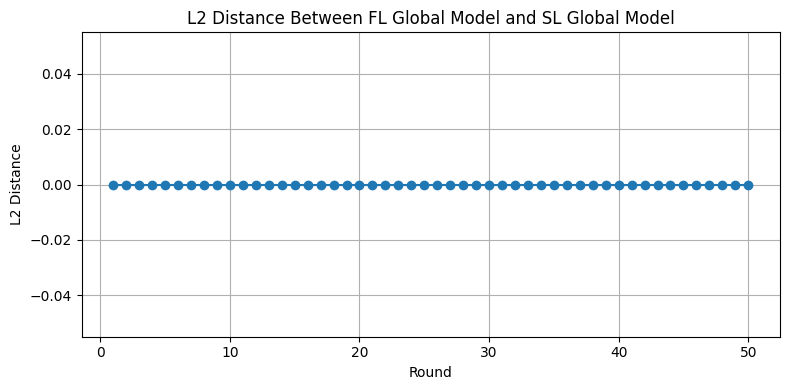

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(results_df["round"], results_df["global_l2_distance_fl_vs_sl"], marker="o")
plt.xlabel("Round")
plt.ylabel("L2 Distance")
plt.title("L2 Distance Between FL Global Model and SL Global Model")
plt.grid(True)
plt.tight_layout()
plt.show()

---

## Cell 18 - Plot FL vs SL Accuracy

This plot compares practical model performance. Similar accuracy supports the claim that both approaches learn similarly, but it does not replace the L2 weight comparison.


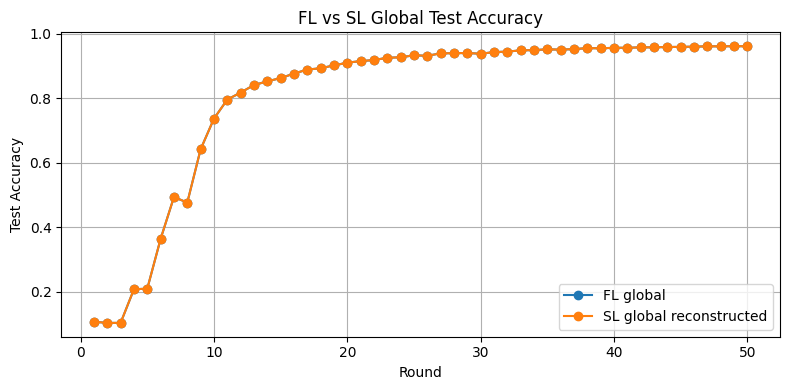

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(results_df["round"], results_df["fl_test_acc"], marker="o", label="FL global")
plt.plot(results_df["round"], results_df["sl_test_acc"], marker="o", label="SL global reconstructed")
plt.xlabel("Round")
plt.ylabel("Test Accuracy")
plt.title("FL vs SL Global Test Accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

---

## Cell 19 - Plot FL vs SL Test Loss

Loss is useful because it can reveal differences that accuracy hides. Two models may have the same accuracy but different confidence levels.


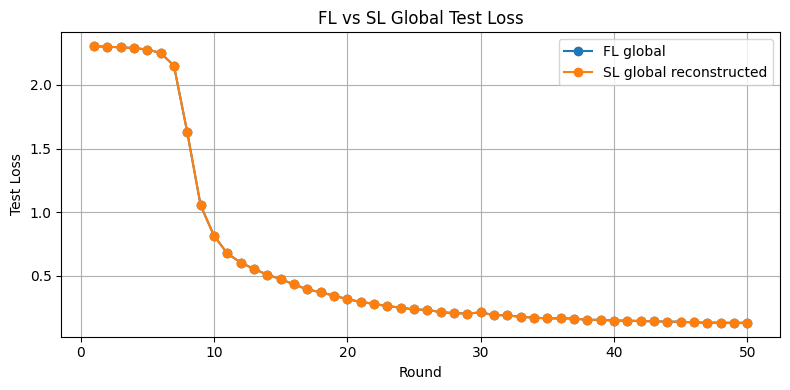

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(results_df["round"], results_df["fl_test_loss"], marker="o", label="FL global")
plt.plot(results_df["round"], results_df["sl_test_loss"], marker="o", label="SL global reconstructed")
plt.xlabel("Round")
plt.ylabel("Test Loss")
plt.title("FL vs SL Global Test Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

---

## Cell 20 - Save Result Tables

This cell saves the experiment outputs so they can be included in a report, plotted later, or compared against future experiments.


In [21]:
results_df.to_csv(os.path.join(SAVE_DIR, "fl_vs_sl_round_results.csv"), index=False)
layerwise_l2_df.to_csv(os.path.join(SAVE_DIR, "fl_vs_sl_layerwise_l2.csv"), index=False)

print("Saved results to:", SAVE_DIR)

Saved results to: /home/raed/Documents/Masters_project_SFL_servers/weights/04


---

## Interpretation Notes

### What should we expect?

If the FL and SL implementations are perfectly equivalent under this Design 1 setup, then:

```text
L2(FL global, SL global) should be zero or very close to zero.
```

Small non-zero values may occur due to floating-point computation order or split-boundary gradient handling.

### Why Design 1 is important

In this design, each client starts from the same round-start global model. For SL, this means:

* each client receives the same round-start client-side layers
* the server uses the same round-start server-side layers for each client's independent training path
* only after all clients finish are weights aggregated

This mirrors the FL training/aggregation process and makes the comparison meaningful.

### Main metric

The main metric is:

```text
L2(FL_global_round_r, SL_global_round_r)
```

calculated after every round.
